<a href="https://colab.research.google.com/github/subhrajit77/Palm-Plant-Disease-detection-using-ML-DL/blob/main/palm2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# General
import os
import shutil
import random
import numpy as np

# Image processing
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Model building
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For splitting data
from sklearn.model_selection import train_test_split

In [ ]:

raw_data_path = '/content/drive/MyDrive/Raw Data'

# Processed data folder
processed_data_path = '/content/drive/MyDrive/Final_Data2'

# Folders for train, val, test
train_dir = os.path.join(processed_data_path, 'train')
val_dir = os.path.join(processed_data_path, 'val')
test_dir = os.path.join(processed_data_path, 'test')

# Classes
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Create folders
for dir_path in [train_dir, val_dir, test_dir]:
    for class_name in classes:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)


In [ ]:
def split_data(class_folder, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    images = os.listdir(os.path.join(raw_data_path, class_folder))
    random.shuffle(images)

    total_images = len(images)
    train_count = int(total_images * train_ratio)
    val_count = int(total_images * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count+val_count]
    test_images = images[train_count+val_count:]

    for image in train_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(train_dir, class_folder, image))

    for image in val_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(val_dir, class_folder, image))

    for image in test_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(test_dir, class_folder, image))

# Apply splitting for all classes
for class_name in classes:
    split_data(class_name)


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define paths
base_dir = '/content/drive/MyDrive/Final_Data2'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Simple preprocessing without augmentation
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1510 images belonging to 4 classes.
Found 215 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [ ]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Define augmentation generator
augmentor = ImageDataGenerator(
    rotation_range=20,              # rotate up to 20 degrees
    width_shift_range=0.1,           # shift horizontally up to 10%
    height_shift_range=0.1,          # shift vertically up to 10%
    zoom_range=0.2,                  # zoom in/out by 20%
    shear_range=0.1,                 # shear transformation
    horizontal_flip=True,            # horizontal flip
    fill_mode='nearest',             # fill missing pixels after transformation
    brightness_range=[0.7, 1.3],     # vary brightness between 70% (darker) and 130% (brighter)
    channel_shift_range=30.0         # random shift in the RGB color channels to simulate contrast variations
)

# Paths
train_dir = '/content/drive/MyDrive/Final_Data2/train'
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Augment training images
def augment_class_images(class_folder, augment_times=3):  # 3 augmented per image
    class_path = os.path.join(train_dir, class_folder)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in tqdm(images, desc=f'Augmenting {class_folder}'):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        base_name = os.path.splitext(img_name)[0]

        i = 0
        for batch in augmentor.flow(x, batch_size=1):
            i += 1
            aug_img_name = f'{base_name}_aug{i}.jpg'
            save_path = os.path.join(class_path, aug_img_name)
            save_img(save_path, batch[0].astype('uint8'))
            if i >= augment_times:
                break

# augmentation for all classes
for class_name in classes:
    augment_class_images(class_name)


Augmenting Stage3: 100%|██████████| 200/200 [00:17<00:00, 11.25it/s]


In [ ]:


import os

train_dir = '/content/drive/MyDrive/Final_Data/train'
image_extensions = ('.jpg', '.jpeg', '.png')  # Add other extensions if needed

total_images = 0
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    if os.path.isdir(class_path):  # Ensure it's a directory, not a file
        for filename in os.listdir(class_path):
            if filename.lower().endswith(image_extensions):
                total_images += 1
print(f"Total number of images in the 'train' folder: {total_images}")


Total number of images in the 'train' folder: 6040


In [ ]:

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(classes), activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'classes' is not defined

In [ ]:
# Callbacks
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# checkpoint = ModelCheckpoint('vgg16_best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=150
    # callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 460ms/step - accuracy: 0.6631 - loss: 3.5912 - val_accuracy: 0.9767 - val_loss: 0.0828
Epoch 2/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.9768 - loss: 0.0618 - val_accuracy: 0.9953 - val_loss: 0.0203
Epoch 3/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9843 - loss: 0.0769 - val_accuracy: 0.9953 - val_loss: 0.0091
Epoch 4/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9938 - loss: 0.0255 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 5/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.9916 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 6/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.9938 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 7/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.9905 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/150
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.9989 - loss: 0.0101 - va

In [ ]:

model_save_path = '/content/drive/MyDrive/Saved Models/palm_saved_2.h5'


import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/drive/MyDrive/Saved Models/palm_saved_2.h5


In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 710ms/step - accuracy: 0.9910 - loss: 0.1149
Test Accuracy: 99.31%


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 495ms/step


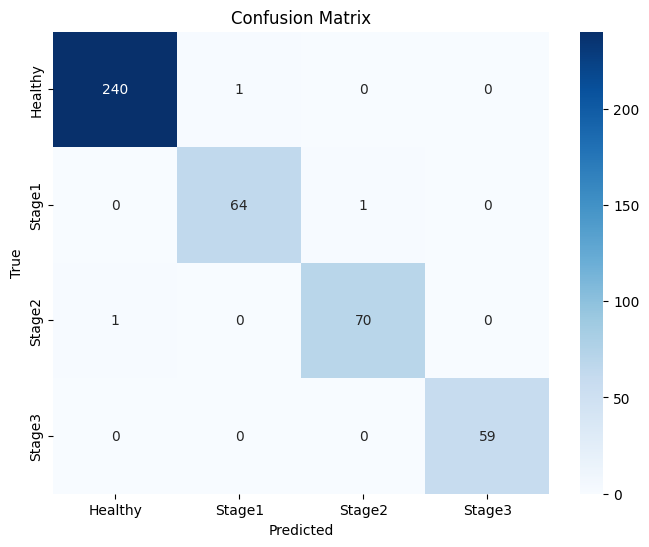


Classification Report:

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       241
      Stage1       0.98      0.98      0.98        65
      Stage2       0.99      0.99      0.99        71
      Stage3       1.00      1.00      1.00        59

    accuracy                           0.99       436
   macro avg       0.99      0.99      0.99       436
weighted avg       0.99      0.99      0.99       436



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)


y_true = test_generator.classes


class_labels = list(test_generator.class_indices.keys())

# 2. Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


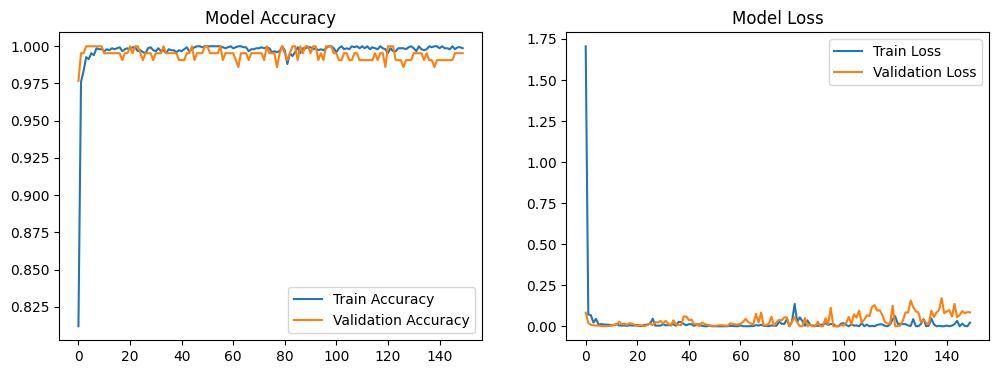

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

In [ ]:
# Final Training & Validation Accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

# Test Accuracy
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Final Training Accuracy: 99.87%
Final Validation Accuracy: 99.53%
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.9910 - loss: 0.1149
Test Accuracy: 99.31%


In [ ]:

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def predict_on_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    class_idx = np.argmax(preds[0])
    class_labels = list(test_generator.class_indices.keys())

    predicted_class = class_labels[class_idx]
    confidence = preds[0][class_idx]

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

    return predicted_class, confidence

# # Load  trained model
# from tensorflow.keras.models import load_model
# model = load_model('wsd_detection_model.h5')


image_path = '/content/drive/MyDrive/Final_Data2/test/Stage1/wsphase1-473.jpg'
predicted_class, confidence = predict_on_image(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: Stage1
Confidence: 1.00


Train for 180 epochs


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/Saved Models/palm_saved_2.h5')

In [ ]:
# General
import os
import shutil
import random
import numpy as np

# Image processing
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Model building
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For splitting data
from sklearn.model_selection import train_test_split

In [ ]:
# Classes
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define paths
base_dir = '/content/drive/MyDrive/Final_Data2'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Simple preprocessing without augmentation
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 6040 images belonging to 4 classes.
Found 215 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [ ]:

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(classes), activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    train_generator,
    epochs=30,  # Continue for 30 more epochs only
    validation_data=val_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 14/189 ━━━━━━━━━━━━━━━━━━━━ 32:56 11s/step - accuracy: 0.4066 - loss: 7.5170

KeyboardInterrupt: 